# Notebook for visualization of a simulated dataset

In [1]:
# Import simulated datasets from simulated_dataset_1 and plot it
from simulated_dataset import SimulatedDataset
import os

In [2]:
import numpy as np
param_datasets_3 = np.load('/path/to/HyperNSDE/datasets/Simu_OU/simulated_dataset_3/params_model.npy', allow_pickle=True)
param_datasets_old_OU = np.load('/path/to/HyperNSDE/datasets/Simu_OU/OU_irreg_n1000_t100_xi005_dim3/params_OU.npy', allow_pickle=True)
print(param_datasets_old_OU)
print(param_datasets_3)

[[[-0.21910341 -0.02313066]
  [ 0.01711867  0.07949674]
  [-0.08171128 -0.21521864]]

 [[-0.01812491 -0.01833412]
  [-0.00955038 -0.0005305 ]
  [ 0.00339847  0.00456978]]

 [[-0.18353301  0.01285032]
  [ 0.03586144  0.08053784]
  [-0.08838084 -0.22418689]]

 ...

 [[-0.14346798  0.05337782]
  [ 0.05697252  0.0817105 ]
  [-0.09589315 -0.23428837]]

 [[-0.08722116  0.1102739 ]
  [ 0.08661012  0.08335678]
  [-0.10643959 -0.24846971]]

 [[-0.122981    0.07410128]
  [ 0.06776753  0.08231013]
  [-0.09973452 -0.23945369]]]
{'theta': array([[ 0.10716843,  0.19580787, -0.12300692],
       [ 0.09923349,  0.21409297, -0.11399987],
       [ 0.12300821,  0.15930701, -0.14098687],
       ...,
       [ 0.04277671, -0.09857376, -0.04855641],
       [-0.02044529,  0.04711369,  0.02320772],
       [-0.00707742,  0.01630905,  0.00803367]]), 'mu': array([[ 1.44626028, -0.26265943, -0.59823161],
       [ 1.40812854, -0.13424918, -0.63264299],
       [ 1.52237916, -0.51899298, -0.52953935],
       ...,
    

#### Define dataset path and load parameters

In [3]:
# Change this path to your dataset location
dataset_path = os.path.join(os.path.dirname(os.getcwd()), "datasets", "Simu_OU", "simulated_dataset_3")

# Load the dataset
dataset = SimulatedDataset.load(dataset_path)

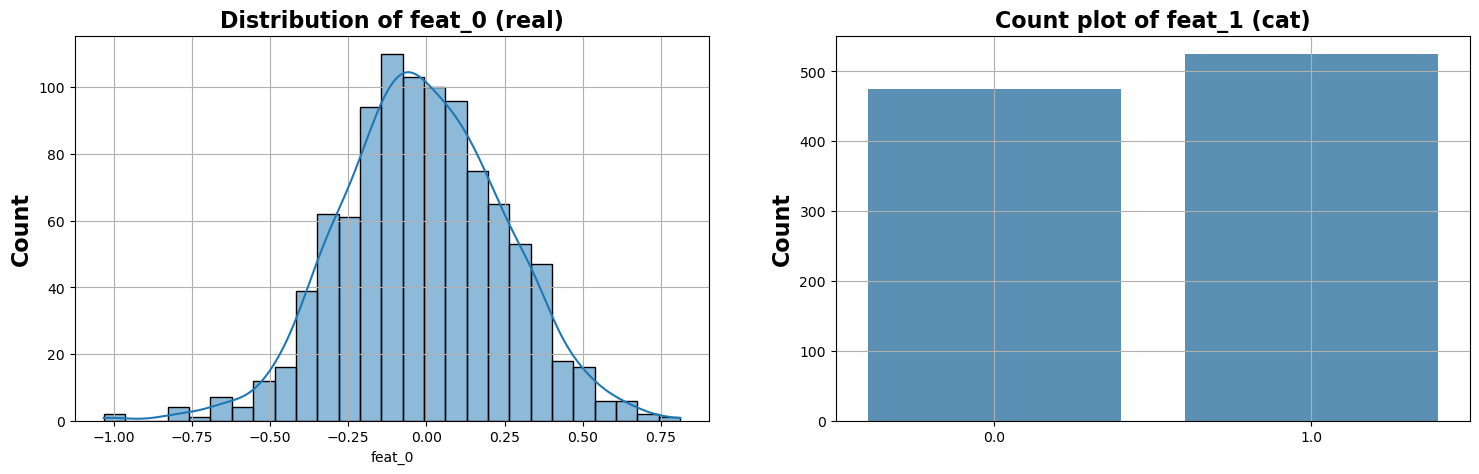

In [4]:
dataset.plot_static_feats()

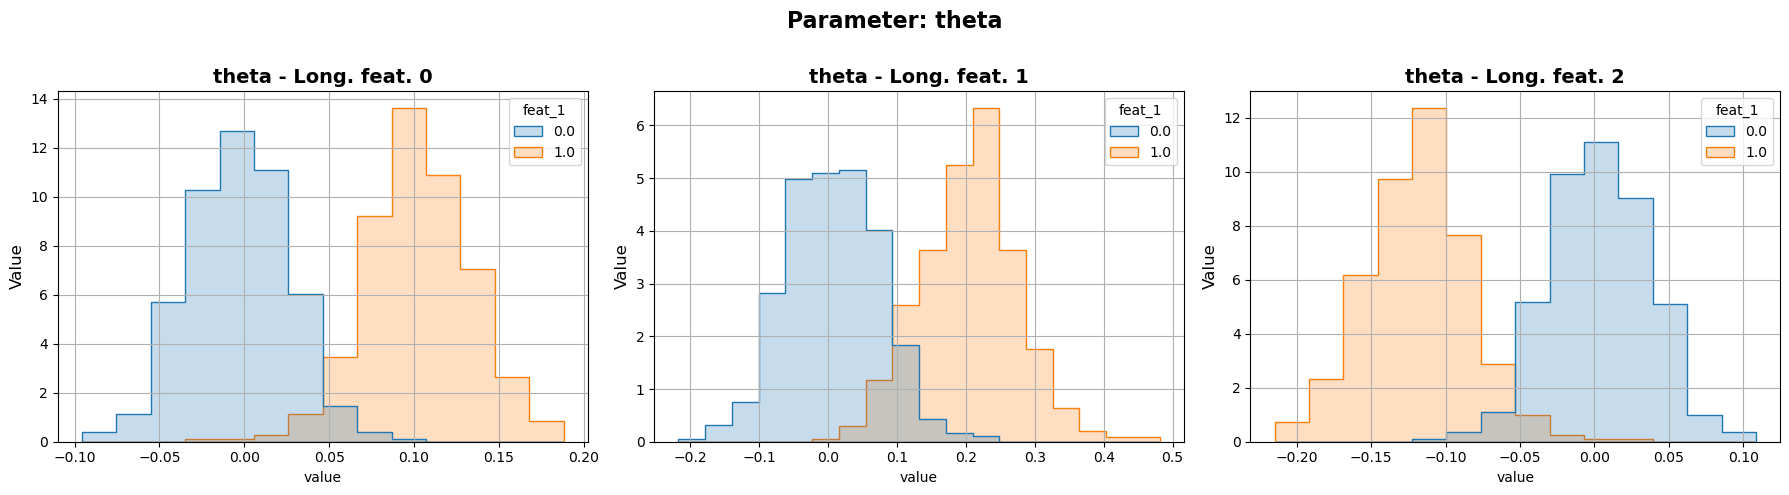

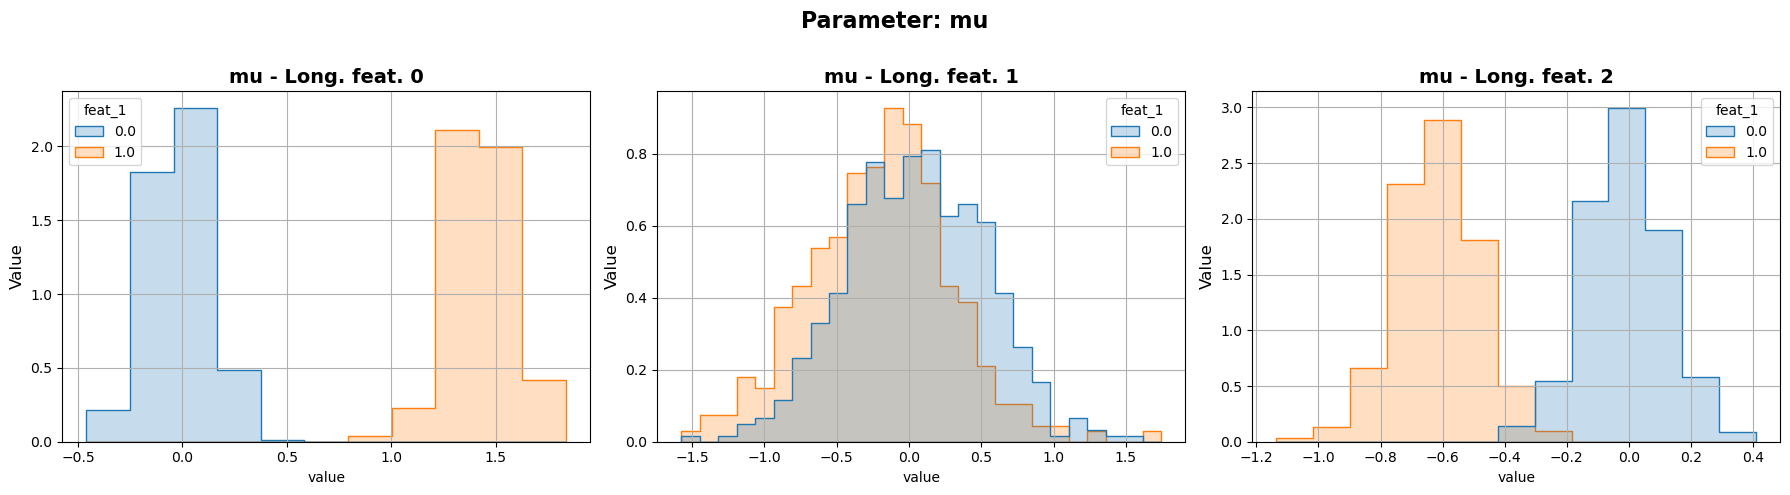

In [5]:
dataset.plot_model_params(feat_comparison_name="feat_1")

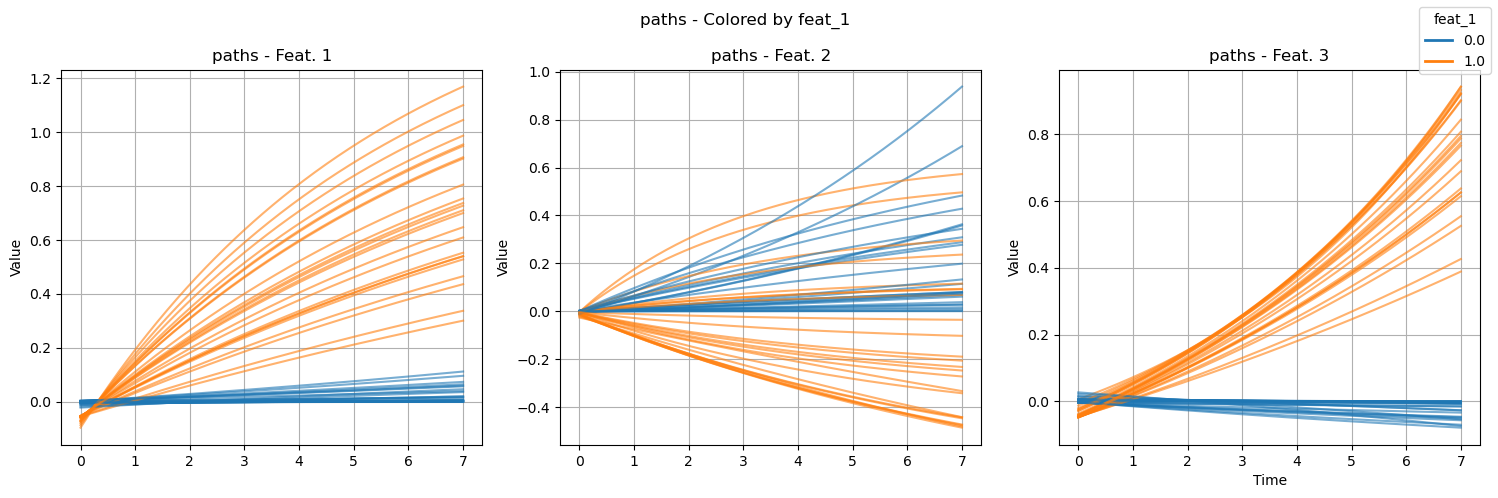

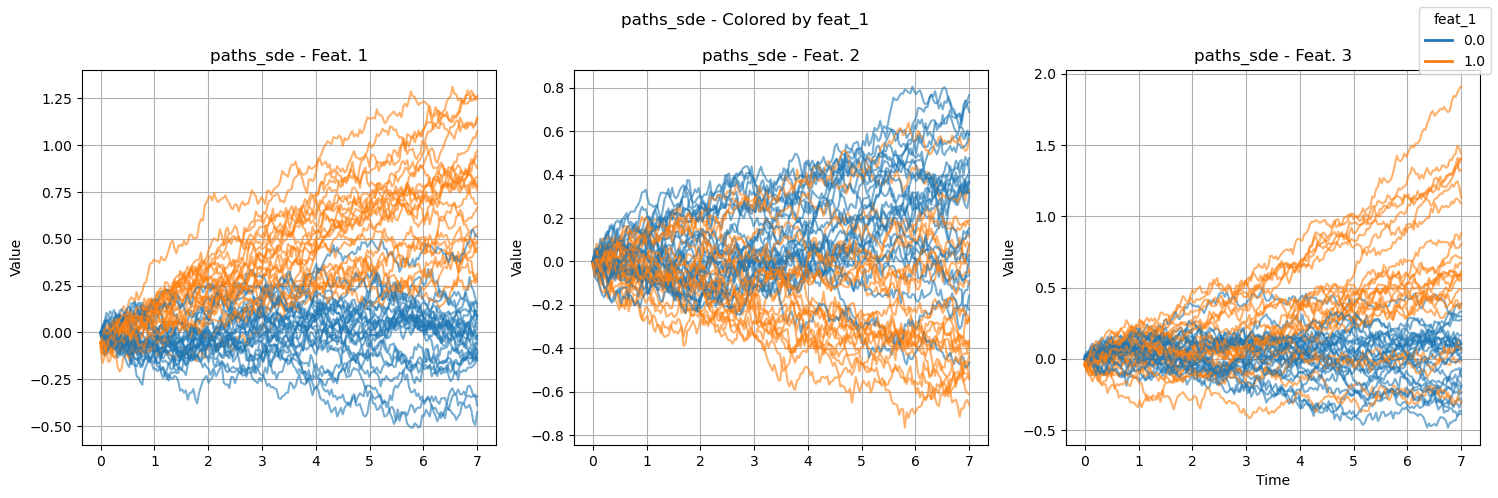

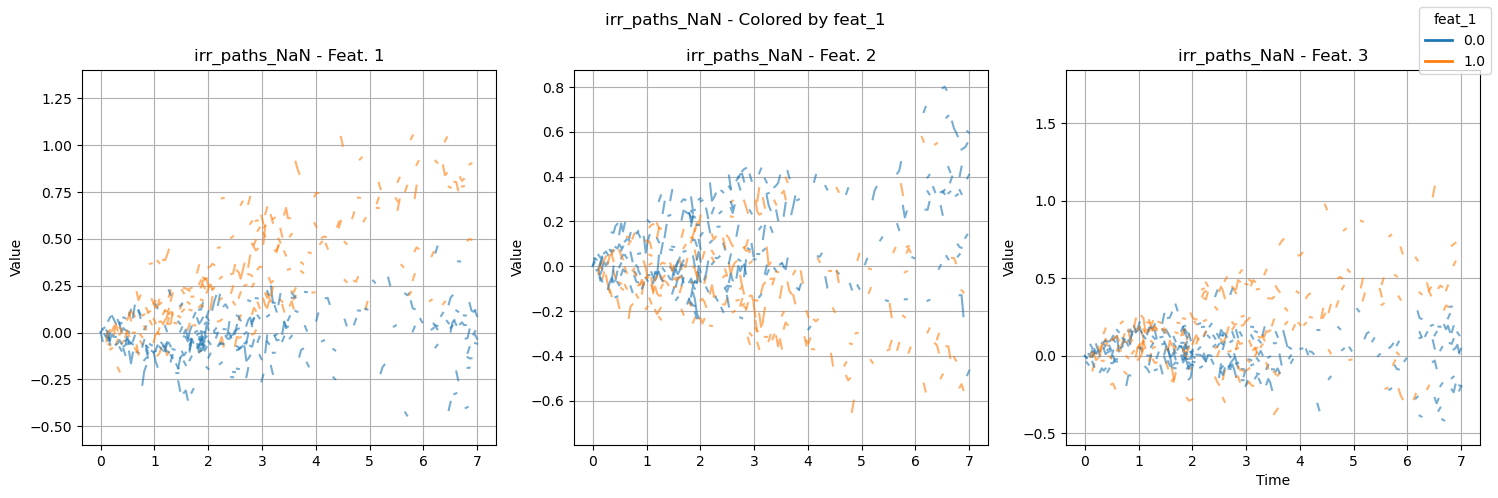

In [6]:
dataset.plot_longitudinal_feats(feat_comparison_name="feat_1", n_samples_to_plot=50)

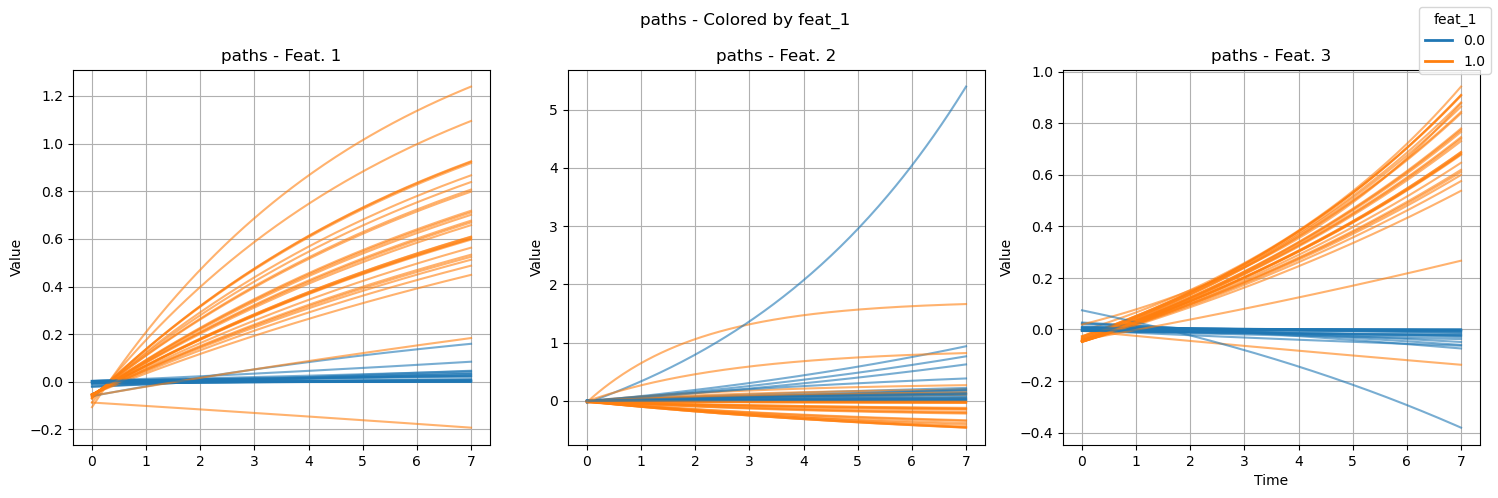

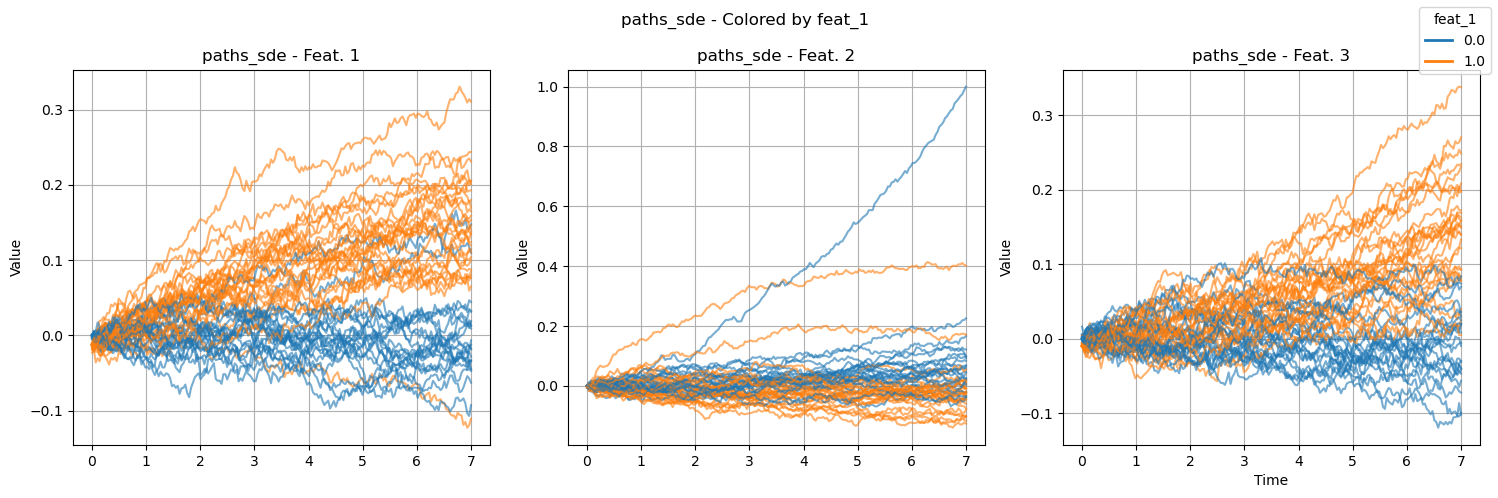

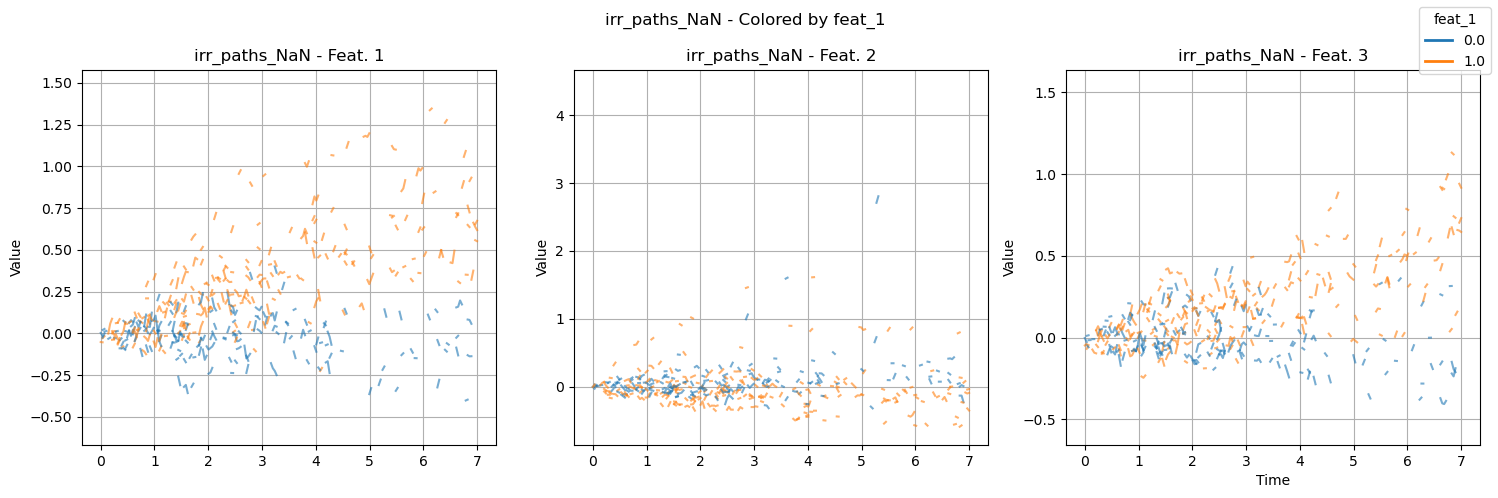

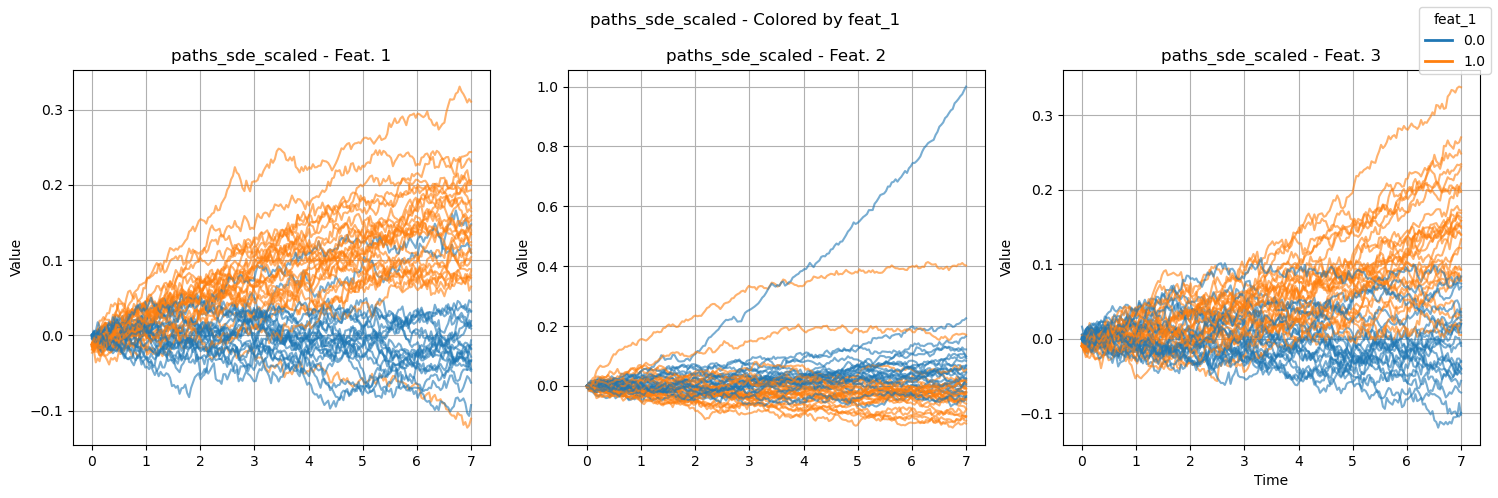

In [9]:
dataset.plot_longitudinal_feats(feat_comparison_name="feat_1", n_samples_to_plot=50, method_scale='absmax')

In [7]:
import torch

def compute_mean_std(x_train, mask_train):

    # Compute mean and std (ignoring masked values)
    sum_vals = torch.sum(x_train * mask_train, dim=[0, 1])  # sum over patients and time
    count_vals = torch.sum(mask_train, dim=[0, 1])  # number of observed values
    mean_vals = sum_vals / count_vals

    squared_diff = (x_train - mean_vals)**2 * mask_train
    std_vals = torch.sqrt(torch.sum(squared_diff, dim=[0, 1]) / count_vals)

    return mean_vals, std_vals

def apply_normalization(x, method="max", mean=None, std=None, max_vals=None, min_vals=None):
    
    # Normalize x
    if method == "max":
        norm_x = x / max_vals
    elif method == "zscore":
        norm_x = (x - mean) / std
    elif method == "min_max":
        norm_x = (x - min_vals) / (max_vals - min_vals + 1e-8)
    else:
        raise ValueError("Unknown normalization method. Use 'max' or 'zscore'.")

    return norm_x

In [8]:
mask = torch.Tensor((~np.isnan(dataset.irr_paths_NaN)).astype(int))
data = torch.Tensor(dataset.irr_paths_NaN)
mean_vals, std_vals = compute_mean_std(data, mask)
norm_x = apply_normalization(data, method='zscore', mean=mean_vals, std=std_vals)